In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings


In [2]:
df = pd.read_csv('/kaggle/input/premier-league-matches/matches.csv')
num_rows, num_cols = df.shape
print(f"Number of rows: {num_rows}")
print(F"Number of columns: {num_cols}")

data_types = df.dtypes
print("\ndata types of each column:")
print(data_types)

categorical_vars = df.select_dtypes(include=['object','category']).columns.tolist()
continuous_vars = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("\nCategorical variables:", categorical_vars)
print("Continuous variables:", continuous_vars)

Number of rows: 4788
Number of columns: 28

data types of each column:
Unnamed: 0        int64
date             object
time             object
comp             object
round            object
day              object
venue            object
result           object
gf                int64
ga                int64
opponent         object
xg              float64
xga             float64
poss              int64
attendance      float64
captain          object
formation        object
referee          object
match report     object
notes           float64
sh                int64
sot               int64
dist            float64
fk                int64
pk                int64
pkatt             int64
season            int64
team             object
dtype: object

Categorical variables: ['date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'opponent', 'captain', 'formation', 'referee', 'match report', 'team']
Continuous variables: ['Unnamed: 0', 'gf', 'ga', 'xg', 'xga', 'poss', 'attendance', 'not

In [7]:
numerical_columns = df.select_dtypes(include=['float64','int64']).columns
five_point_summary = df[numerical_columns]. describe(percentiles=[0.25,0.5,0.75])
print(five_point_summary.loc[['min','25%','50%','75%','max']])

     Unnamed: 0   gf   ga   xg  xga  poss  attendance  notes    sh   sot  \
min         0.0  0.0  0.0  0.0  0.0  18.0      2000.0    NaN   0.0   0.0   
25%        28.0  0.0  0.0  0.8  0.7  41.0     25513.5    NaN   9.0   2.0   
50%        62.0  1.0  1.0  1.3  1.2  51.0     36347.0    NaN  12.0   4.0   
75%        87.0  2.0  2.0  1.9  1.8  60.0     53235.5    NaN  16.0   6.0   
max       182.0  9.0  9.0  7.0  7.0  82.0     75546.0    NaN  36.0  15.0   

     dist   fk   pk  pkatt  season  
min   5.3  0.0  0.0    0.0  2020.0  
25%  15.4  0.0  0.0    0.0  2021.0  
50%  17.2  0.0  0.0    0.0  2023.0  
75%  19.1  1.0  0.0    0.0  2024.0  
max  39.9  4.0  3.0    3.0  2024.0  


In [8]:
categorical_columns = df.select_dtypes(include=['object','category']).columns

for col in categorical_columns:
    print(f"Summary for categorical_variables {col}")
    
    num_categories = df[col].nunique()
    print(F"Number of categories:{num_categories}")
    
    category_counts = df[col].value_counts(normalize=True)*100
    print("Percentage of observation in each category:")
    print(category_counts.to_string())

Summary for categorical_variables date
Number of categories:610
Percentage of observation in each category:
date
2021-05-23    0.835422
2020-07-26    0.543024
2020-10-04    0.501253
2020-12-16    0.501253
2021-05-19    0.501253
2020-12-26    0.501253
2021-01-30    0.501253
2020-01-01    0.480368
2019-12-26    0.480368
2019-08-31    0.438596
2019-11-23    0.438596
2024-05-19    0.417711
2019-11-02    0.417711
2020-12-13    0.417711
2021-01-27    0.417711
2021-02-06    0.417711
2020-02-01    0.417711
2019-09-28    0.417711
2022-05-22    0.417711
2021-02-28    0.417711
2020-12-29    0.417711
2021-02-03    0.417711
2021-01-16    0.417711
2019-10-19    0.417711
2019-09-14    0.417711
2023-05-28    0.417711
2020-01-11    0.396825
2020-01-18    0.396825
2019-12-28    0.355054
2019-12-04    0.355054
2019-08-17    0.355054
2023-02-18    0.334169
2021-05-09    0.334169
2020-03-07    0.334169
2022-10-29    0.334169
2019-12-21    0.334169
2020-09-12    0.334169
2023-04-08    0.334169
2020-10-18   

In [15]:
df.columns


Index(['Unnamed: 0', 'date', 'time', 'comp', 'round', 'day', 'venue', 'result',
       'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'captain',
       'formation', 'referee', 'match report', 'notes', 'sh', 'sot', 'dist',
       'fk', 'pk', 'pkatt', 'season', 'team'],
      dtype='object')

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,4788.0,63.044069,42.865191,0.0,28.0,62.0,87.0,182.0
gf,4788.0,1.447995,1.312635,0.0,0.0,1.0,2.0,9.0
ga,4788.0,1.405388,1.286927,0.0,0.0,1.0,2.0,9.0
xg,4788.0,1.396512,0.828847,0.0,0.8,1.3,1.9,7.0
xga,4788.0,1.364745,0.814947,0.0,0.7,1.2,1.8,7.0
poss,4788.0,50.432957,12.810958,18.0,41.0,51.0,60.0,82.0
attendance,3155.0,38397.586688,17595.849137,2000.0,25513.5,36347.0,53235.5,75546.0
notes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sh,4788.0,12.619256,5.548444,0.0,9.0,12.0,16.0,36.0
sot,4788.0,4.261278,2.459963,0.0,2.0,4.0,6.0,15.0


In [18]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4788 entries, 0 to 4787
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    4788 non-null   int64  
 1   date          4788 non-null   object 
 2   time          4788 non-null   object 
 3   comp          4788 non-null   object 
 4   round         4788 non-null   object 
 5   day           4788 non-null   object 
 6   venue         4788 non-null   object 
 7   result        4788 non-null   object 
 8   gf            4788 non-null   int64  
 9   ga            4788 non-null   int64  
 10  opponent      4788 non-null   object 
 11  xg            4788 non-null   float64
 12  xga           4788 non-null   float64
 13  poss          4788 non-null   int64  
 14  attendance    3155 non-null   float64
 15  captain       4788 non-null   object 
 16  formation     4788 non-null   object 
 17  referee       4788 non-null   object 
 18  match report  4788 non-null 

In [20]:
df.isnull().notnull()/len(df*50)

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,captain,formation,referee,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209
1,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209
2,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209
3,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209
4,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4783,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209
4784,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209
4785,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209
4786,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209,0.000209


<Axes: >

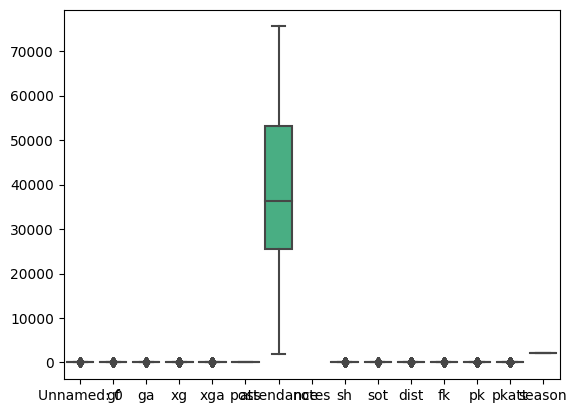

In [25]:
sns.boxplot(df)

<Axes: >

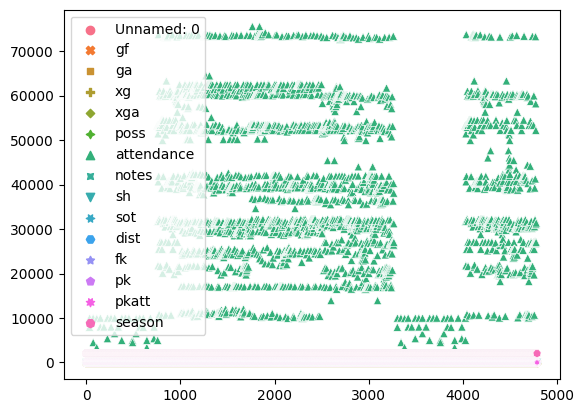

In [26]:
sns.scatterplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


<Axes: >

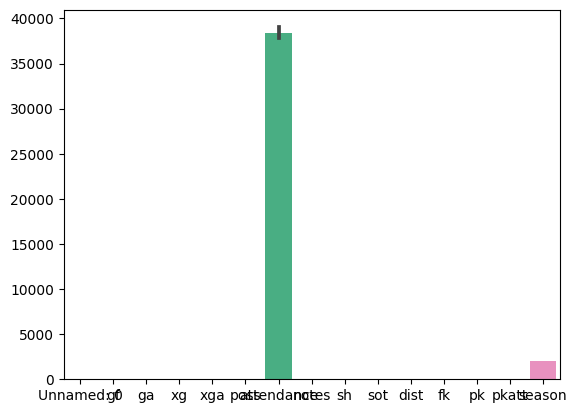

In [27]:
sns.barplot(df)

<Axes: >

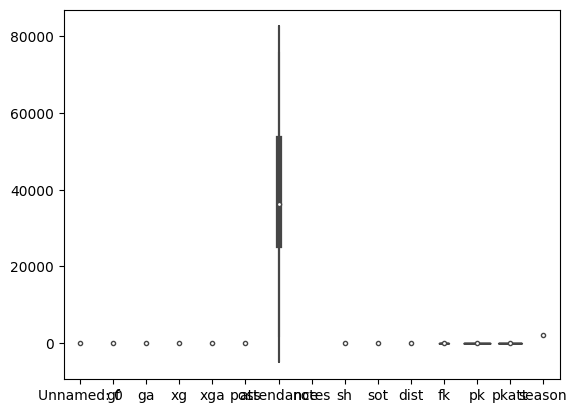

In [28]:
sns.violinplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

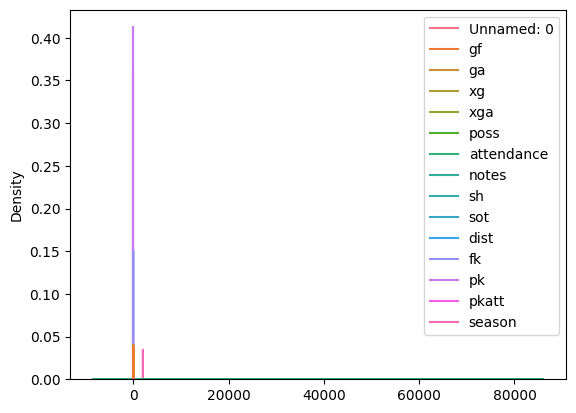

In [30]:
sns.kdeplot(df)

<Axes: ylabel='count'>

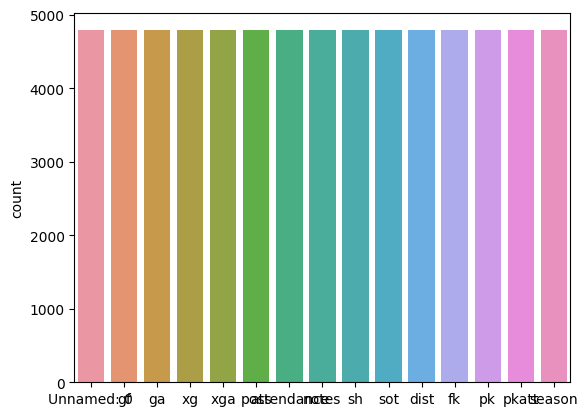

In [31]:
sns.countplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

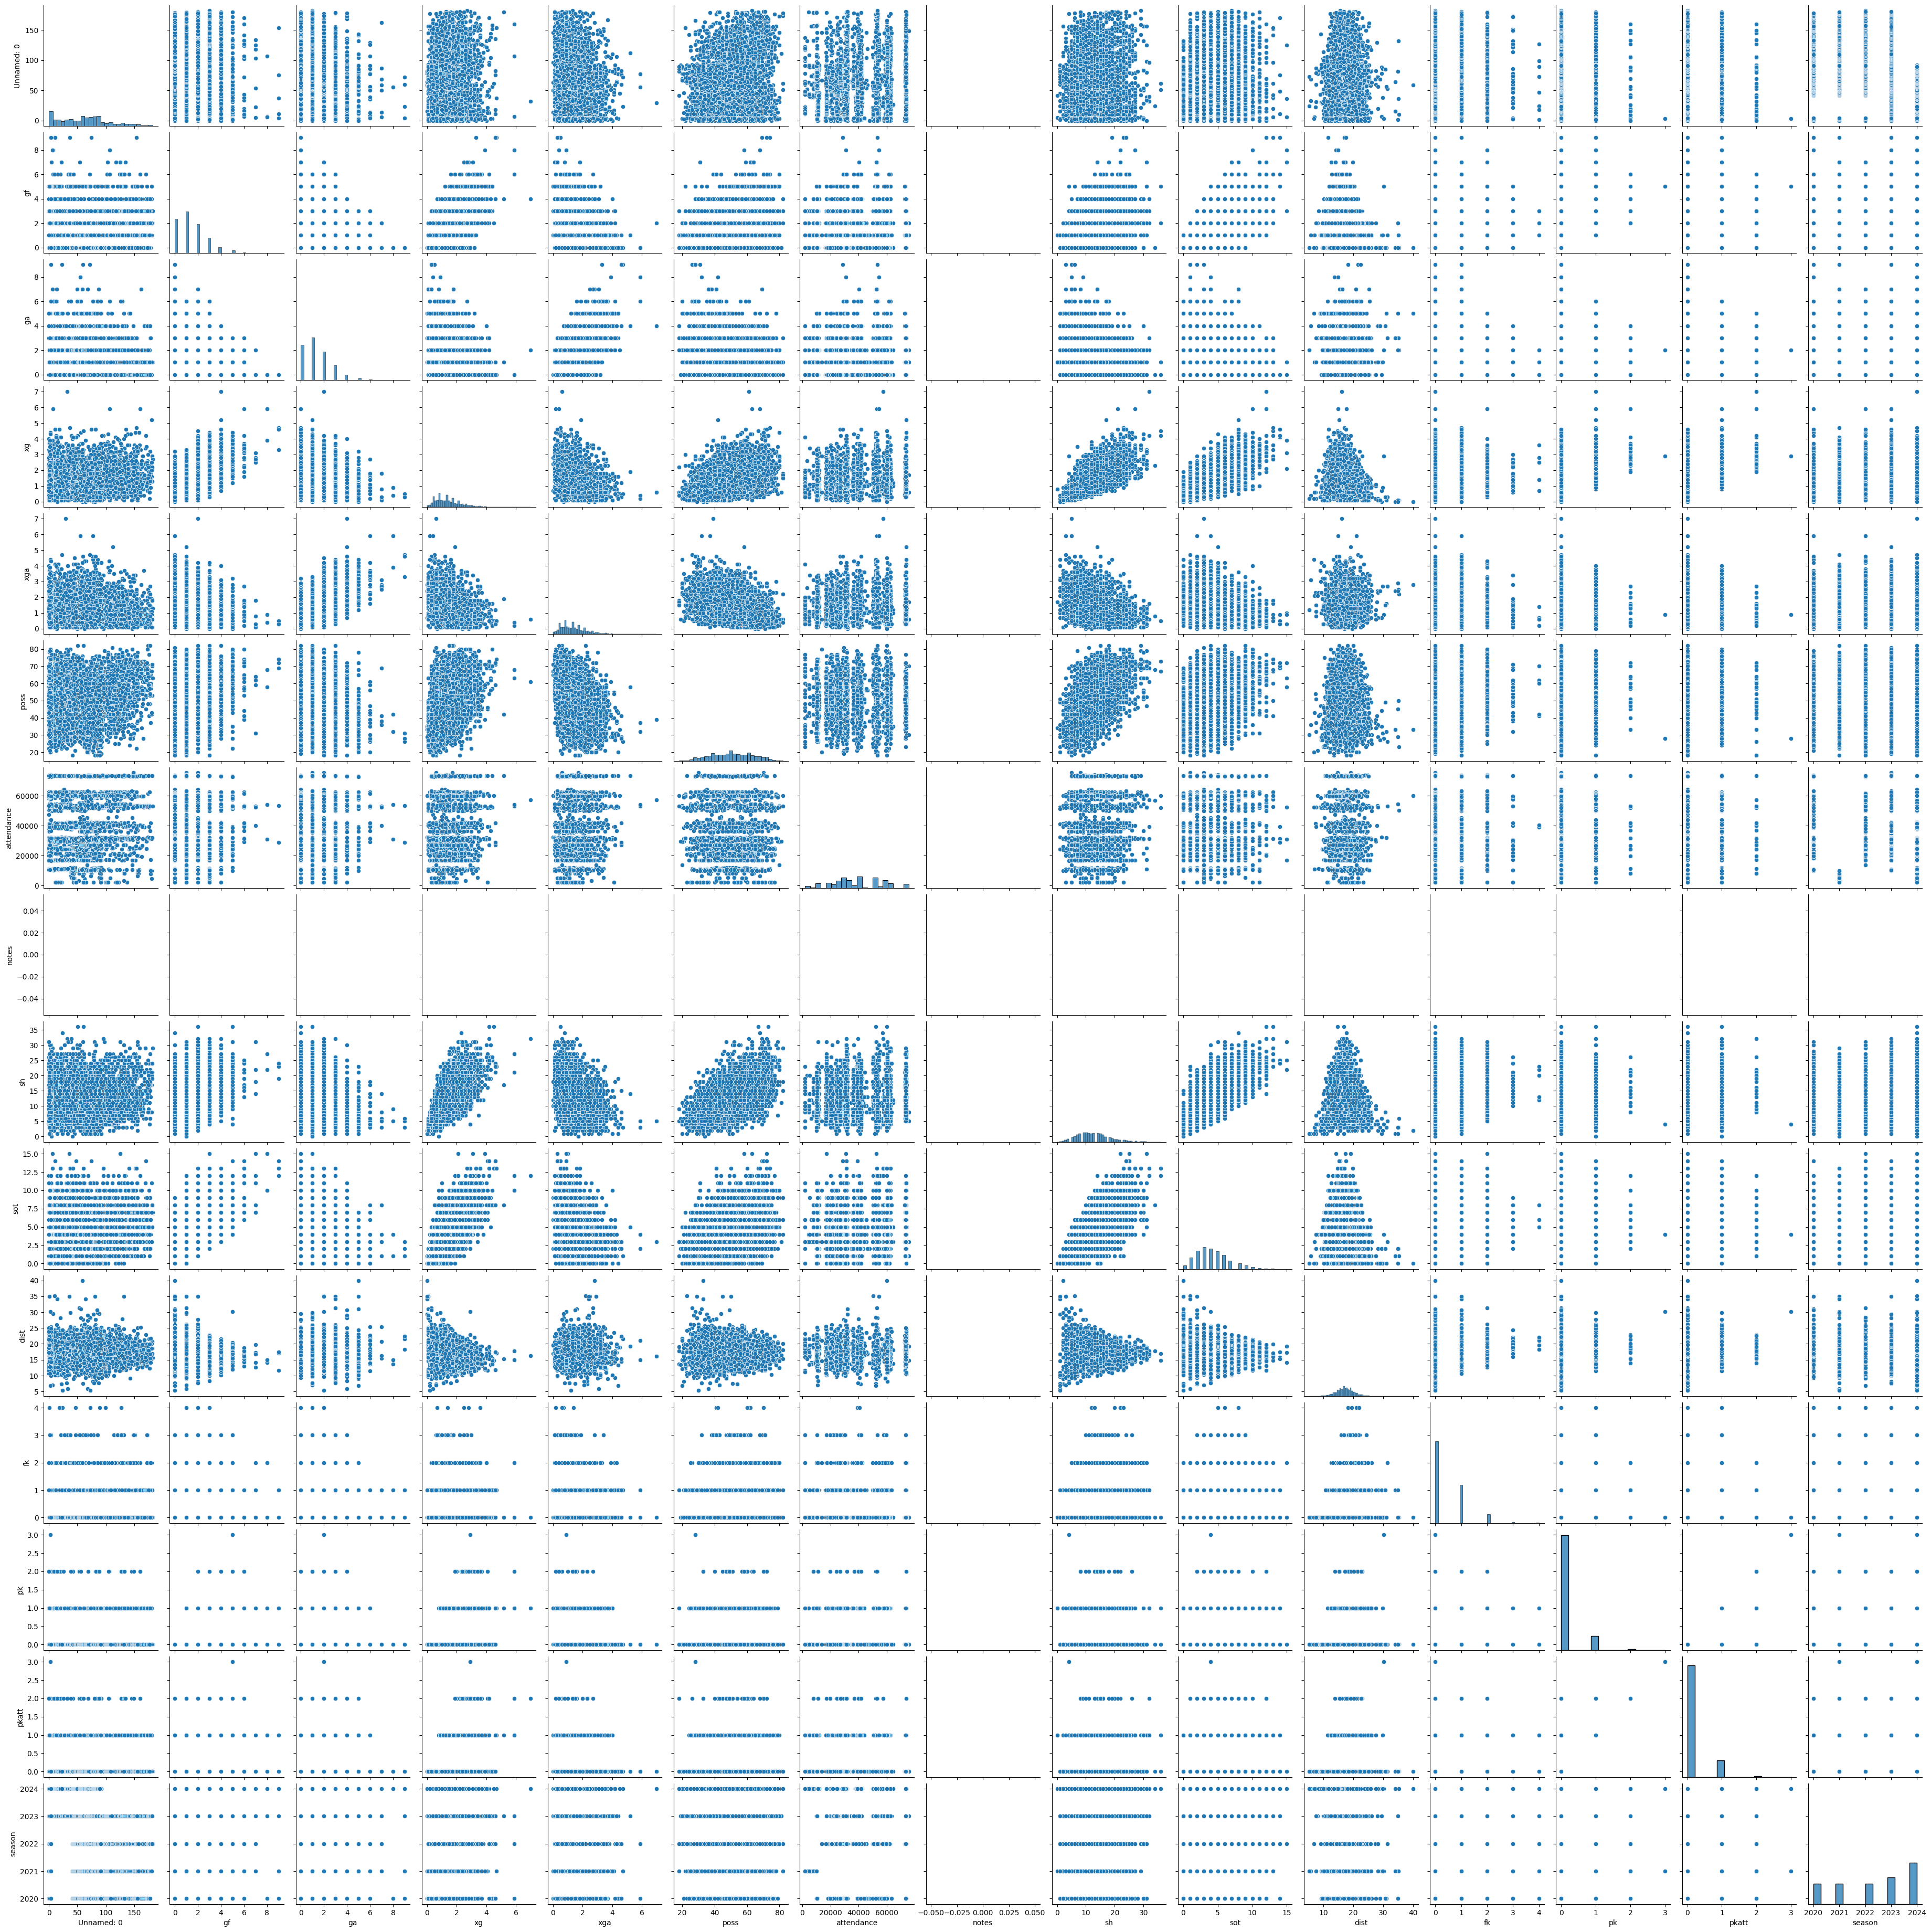

In [32]:
sns.pairplot(df)

In [33]:
cat_cols = df.select_dtypes(include='object')

In [34]:
for i in cat_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*50)

date



time



comp



round



day



venue



result



opponent



captain



formation



referee



match report



team





In [35]:
num_cols = df.select_dtypes(include='number')

In [36]:
for i in num_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*50)

Unnamed: 0



gf



ga



xg



xga



poss



attendance



notes



sh



sot



dist



fk



pk



pkatt



season





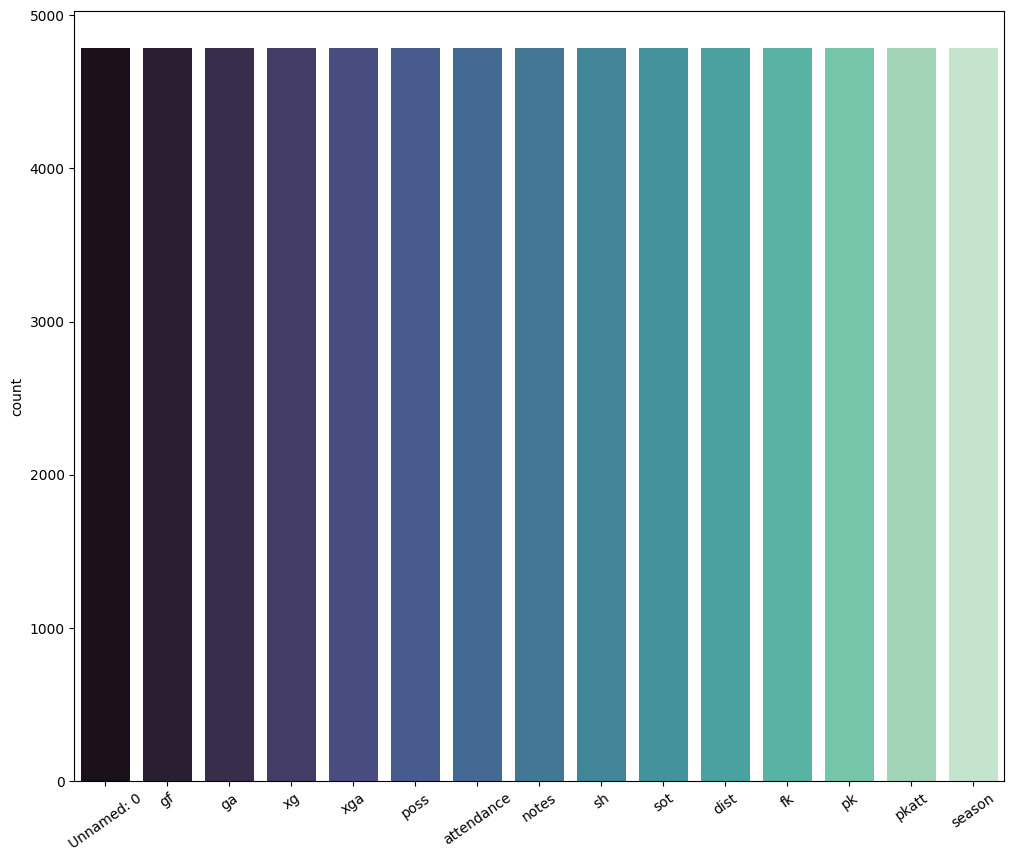

In [38]:
plt.figure(figsize=(12,10))
sns.countplot(data=df,palette='mako');
plt.xticks(rotation=35);
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

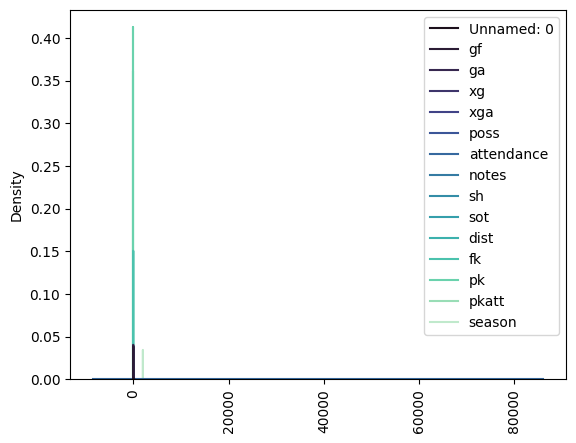

In [39]:
sns.kdeplot(data=df,palette='mako');
plt.xticks(rotation=90)
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


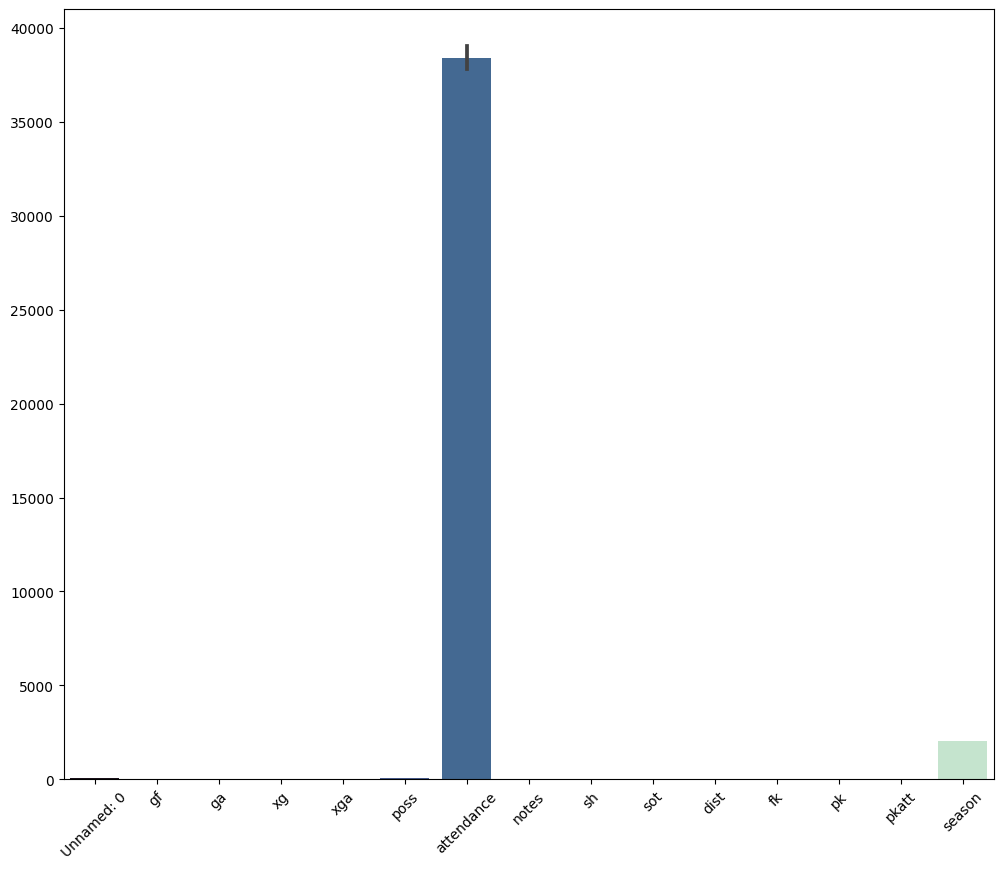

In [40]:
plt.figure(figsize=(12,10))
sns.barplot(data=df,palette='mako');
plt.xticks(rotation=45);
plt.show()

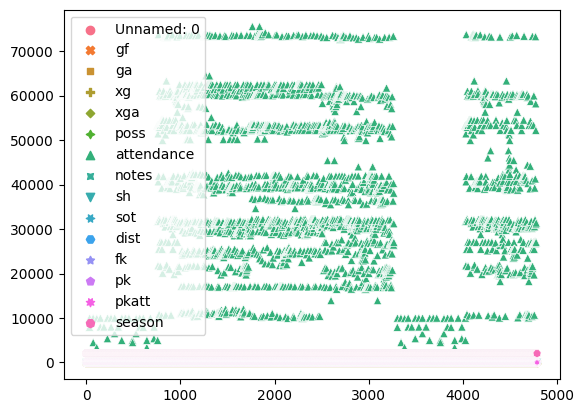

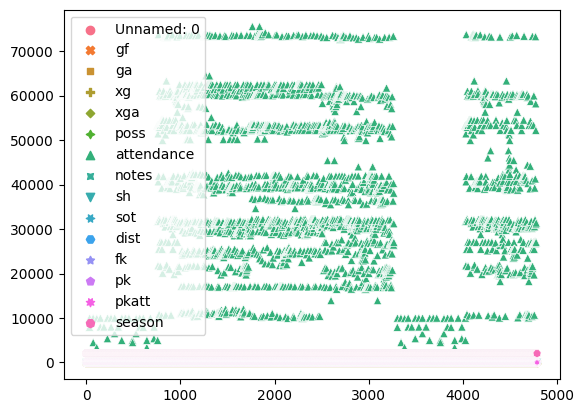

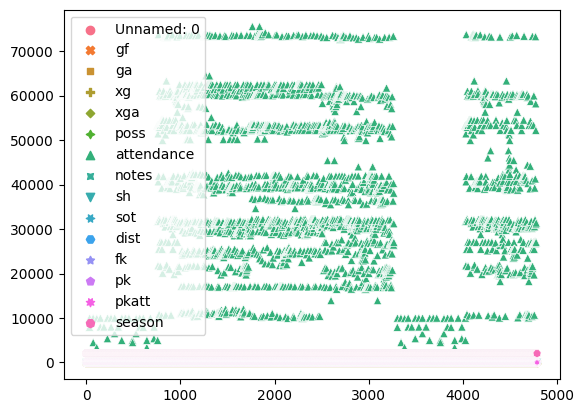

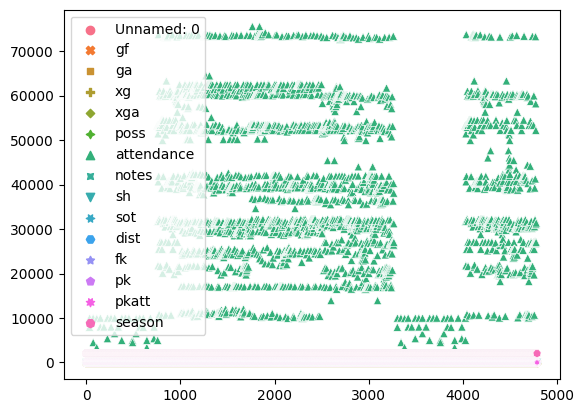

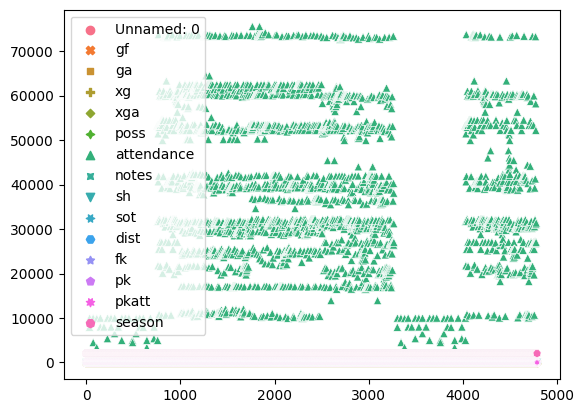

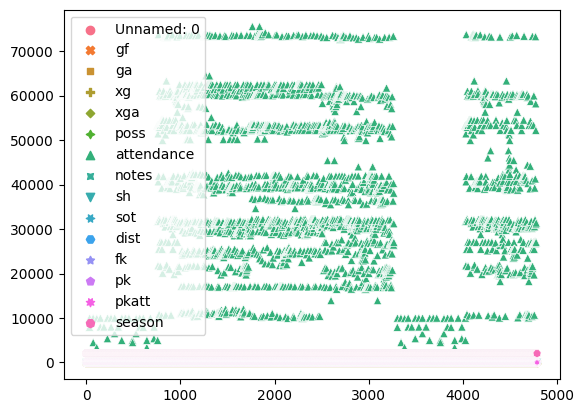

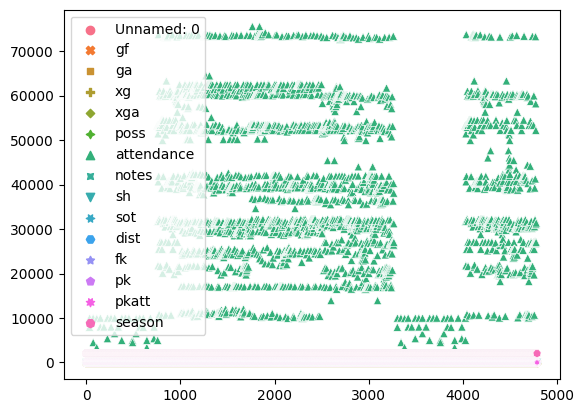

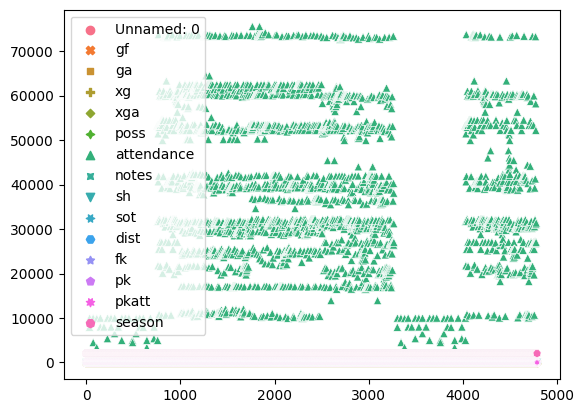

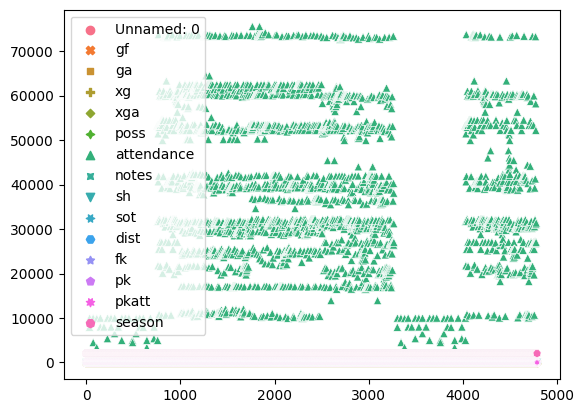

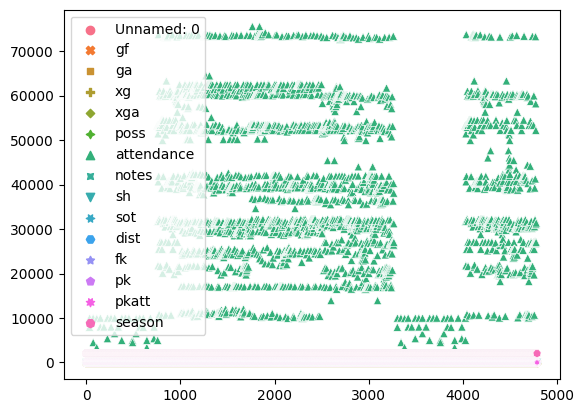

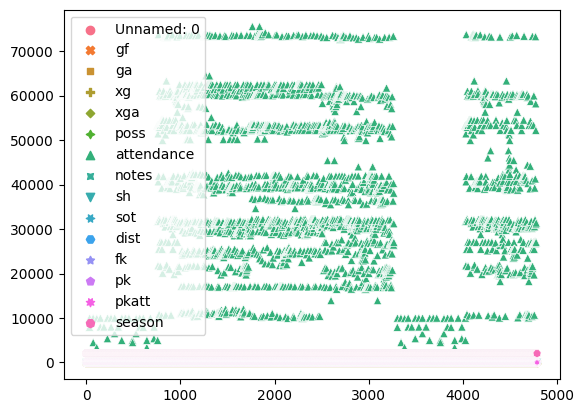

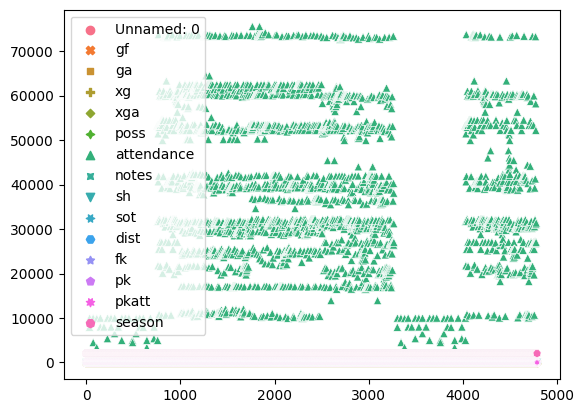

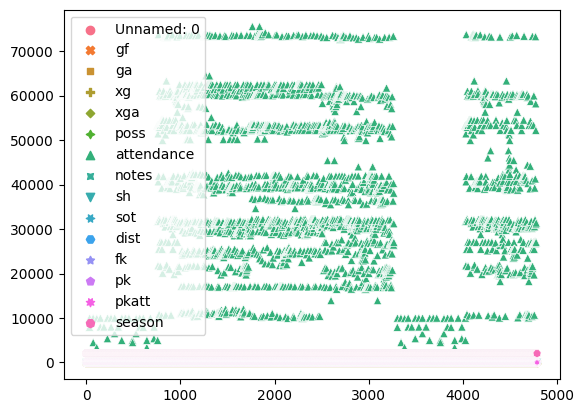

In [41]:
x = 1
cat_cols = df.select_dtypes(include='object')
for i in cat_cols:
    sns.scatterplot(data=df)
    print('\n')
    plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

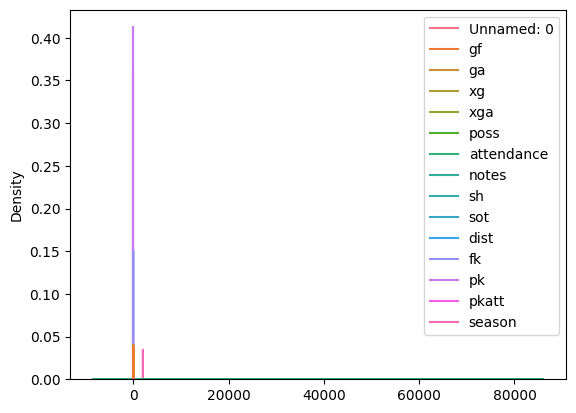

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

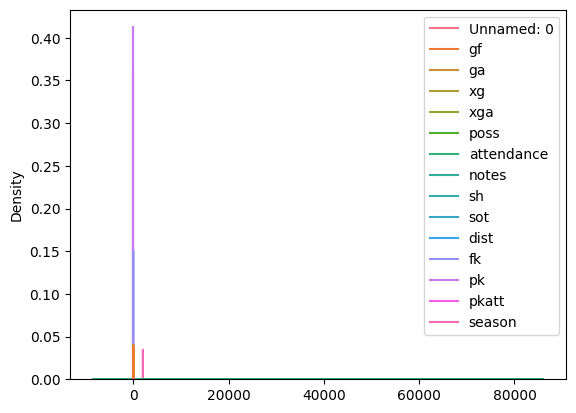

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

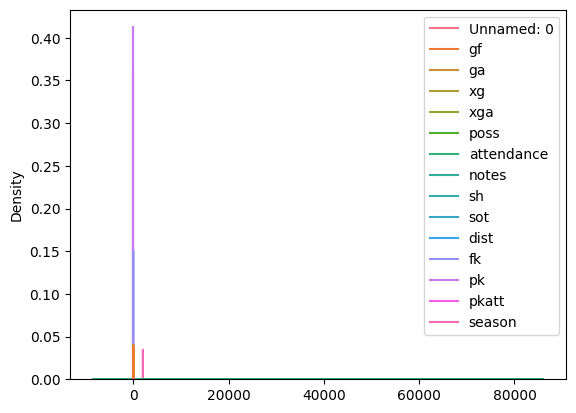

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

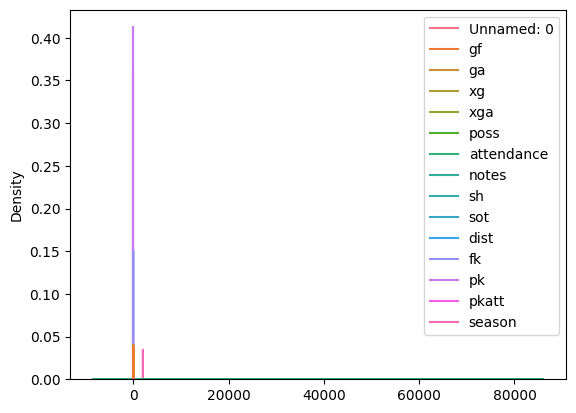

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

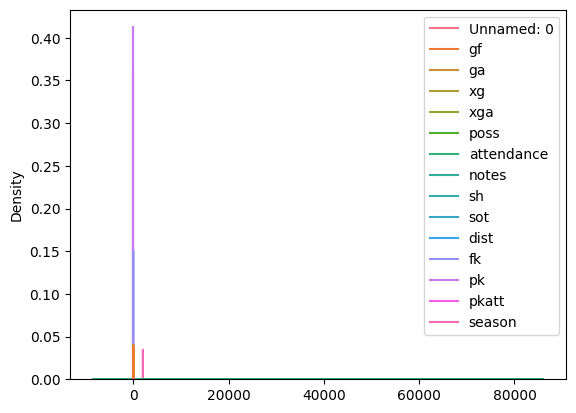

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

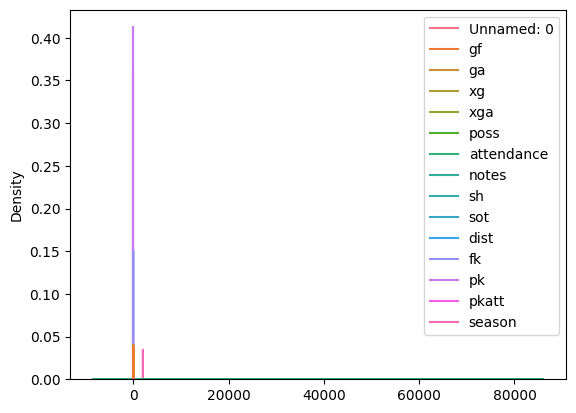

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

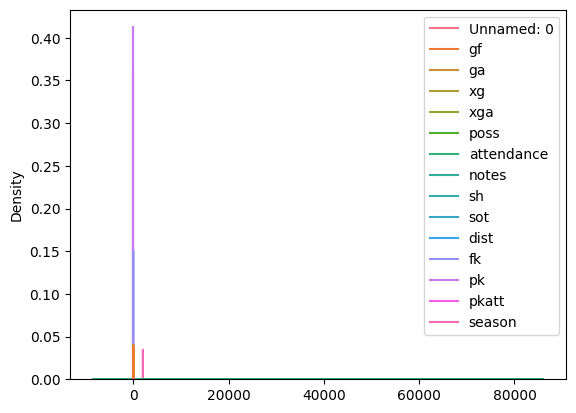

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

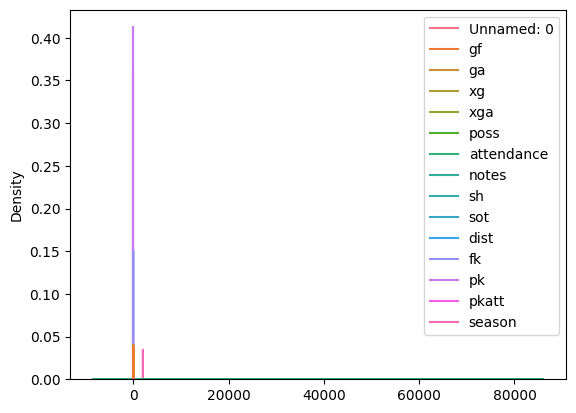

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

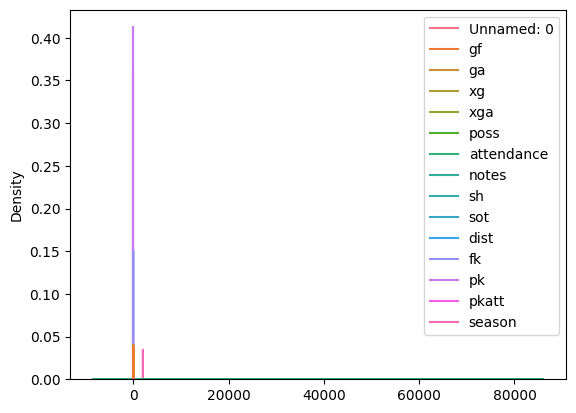

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

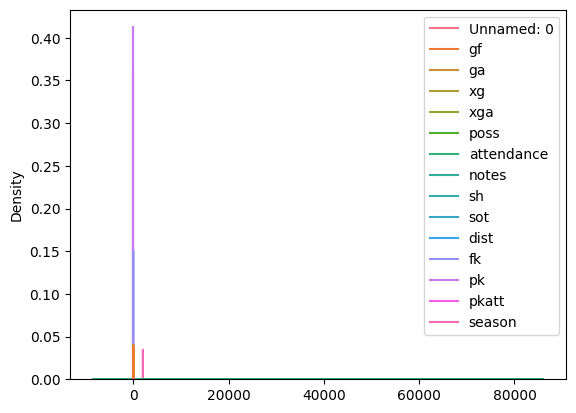

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

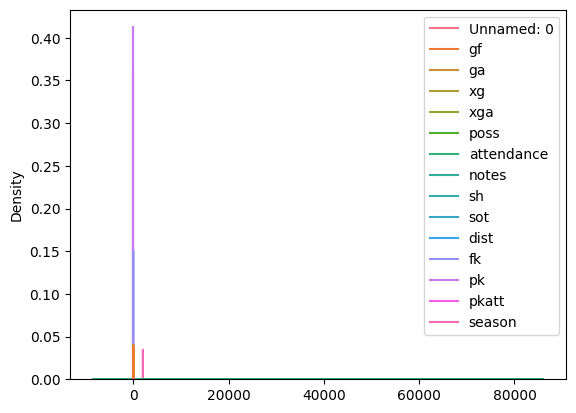

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

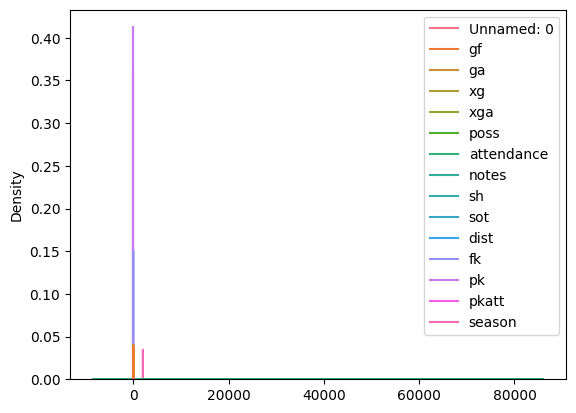

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

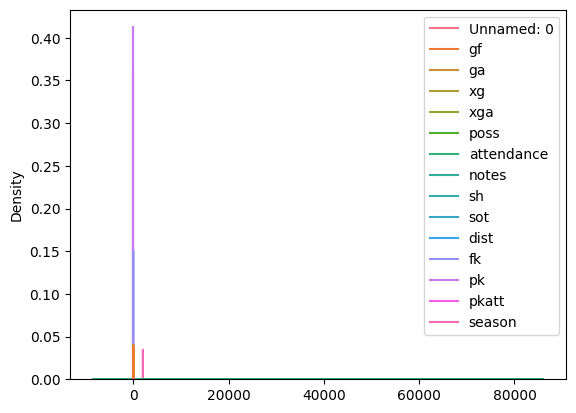

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

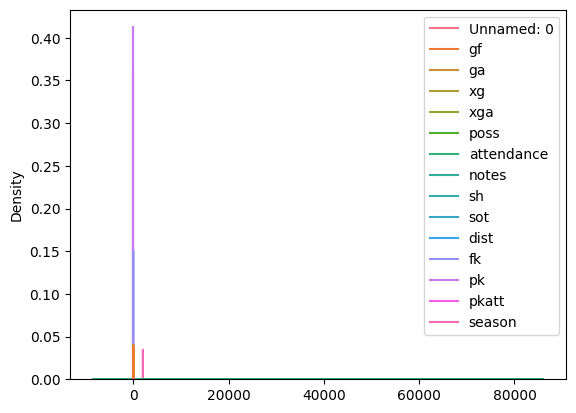

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

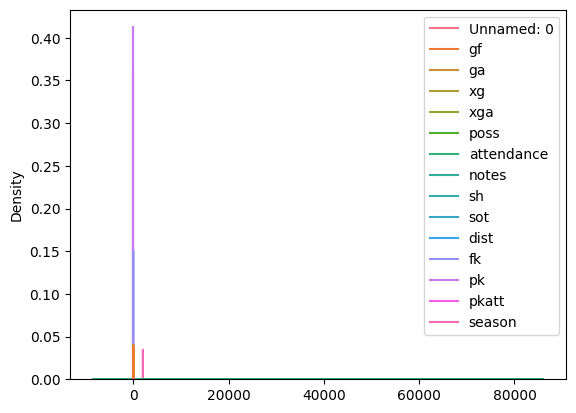

In [42]:
x = 1
num_cols = df.select_dtypes(include='number')
for i in num_cols:
    sns.kdeplot(data=df)
    print('\n')
    plt.show()


In [45]:
df.corr

<bound method DataFrame.corr of       Unnamed: 0        date           time            comp         round  \
0              0  2020-09-21  20:15 (21:15)  Premier League   Matchweek 2   
1              2  2020-09-27  16:30 (17:30)  Premier League   Matchweek 3   
2              4  2020-10-03  17:30 (18:30)  Premier League   Matchweek 4   
3              5  2020-10-17  17:30 (18:30)  Premier League   Matchweek 5   
4              7  2020-10-24  12:30 (13:30)  Premier League   Matchweek 6   
...          ...         ...            ...             ...           ...   
4783          87  2020-07-07  18:00 (19:00)  Premier League  Matchweek 34   
4784          88  2020-07-11  12:30 (13:30)  Premier League  Matchweek 35   
4785          89  2020-07-14  20:15 (21:15)  Premier League  Matchweek 36   
4786          90  2020-07-18  17:30 (18:30)  Premier League  Matchweek 37   
4787          91  2020-07-26  16:00 (17:00)  Premier League  Matchweek 38   

      day venue result  gf  ga         oppo

In [46]:
df.head()

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,captain,formation,referee,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2020-09-21,20:15 (21:15),Premier League,Matchweek 2,Mon,Away,W,3,1,Wolves,1.9,0.6,65,NaN,Fernandinho,4-2-3-1,Andre Marriner,Match Report,NaN,13,8,21.1,2,1,1,2024,Manchester City
1,2,2020-09-27,16:30 (17:30),Premier League,Matchweek 3,Sun,Home,L,2,5,Leicester City,0.9,2.9,72,NaN,Fernandinho,4-2-3-1,Michael Oliver,Match Report,NaN,16,5,19.8,1,0,0,2024,Manchester City
2,4,2020-10-03,17:30 (18:30),Premier League,Matchweek 4,Sat,Away,D,1,1,Leeds United,1.2,2.4,49,NaN,Kevin De Bruyne,4-3-3,Mike Dean,Match Report,NaN,23,1,18.2,1,0,0,2024,Manchester City
3,5,2020-10-17,17:30 (18:30),Premier League,Matchweek 5,Sat,Home,W,1,0,Arsenal,1.3,0.9,58,NaN,Raheem Sterling,3-1-4-2,Chris Kavanagh,Match Report,NaN,13,5,17.7,0,0,0,2024,Manchester City
4,7,2020-10-24,12:30 (13:30),Premier League,Matchweek 6,Sat,Away,D,1,1,West Ham,1.0,0.3,69,NaN,Raheem Sterling,4-3-3,Anthony Taylor,Match Report,NaN,14,7,20.9,1,0,0,2024,Manchester City


Correlations with poss variables:
sh            0.553565
xg            0.366729
sot           0.357195
gf            0.179932
fk            0.130683
Unnamed: 0    0.114441
pkatt         0.048199
pk            0.038243
season        0.014603
attendance    0.009149
dist         -0.027335
ga           -0.177737
xga          -0.367116
notes              NaN
Name: poss, dtype: float64


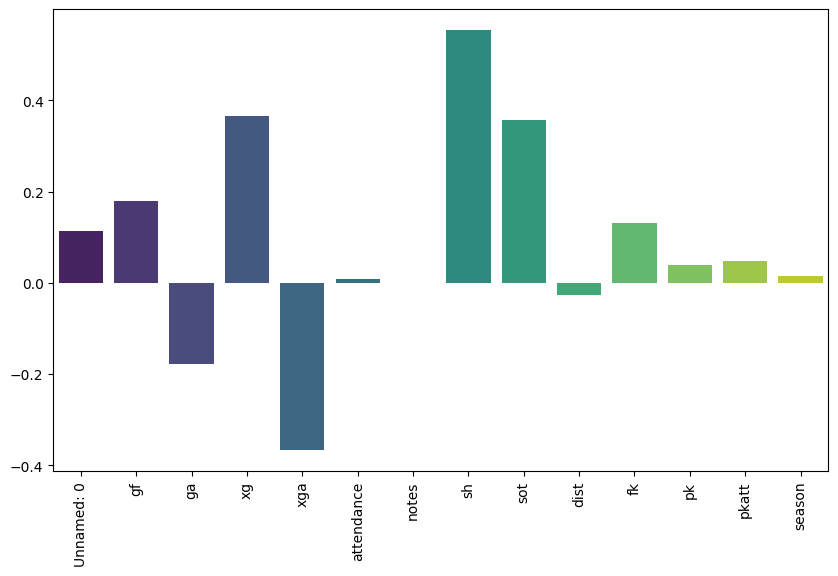

In [49]:
poss = 'poss'
if poss in df.columns:
    df_numerical = df.select_dtypes(include=['int64','float64'])
    correlations = df_numerical.corr()[poss].drop(poss)
    print("Correlations with poss variables:")
    print(correlations.sort_values(ascending=False))
    plt.figure(figsize=(10,6))
    sns.barplot(x=correlations.index,y=correlations.values,palette='viridis')
    plt.xticks(rotation=90)
    plt.show()


    

In [50]:
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
import warnings
warnings.filterwarnings('ignore')

Text(0.5, 1.0, 'Line plot of xg by Table Poss')

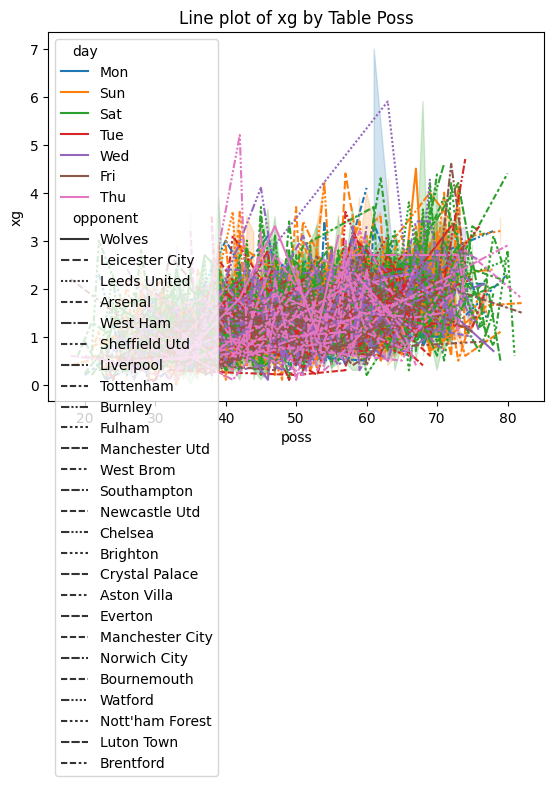

In [54]:
sns.lineplot(x='poss',y='xg',data=df,hue='day',style='opponent')
plt.title("Line plot of xg by Table Poss")


In [51]:
df.head()

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,captain,formation,referee,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2020-09-21,20:15 (21:15),Premier League,Matchweek 2,Mon,Away,W,3,1,Wolves,1.9,0.6,65,NaN,Fernandinho,4-2-3-1,Andre Marriner,Match Report,NaN,13,8,21.1,2,1,1,2024,Manchester City
1,2,2020-09-27,16:30 (17:30),Premier League,Matchweek 3,Sun,Home,L,2,5,Leicester City,0.9,2.9,72,NaN,Fernandinho,4-2-3-1,Michael Oliver,Match Report,NaN,16,5,19.8,1,0,0,2024,Manchester City
2,4,2020-10-03,17:30 (18:30),Premier League,Matchweek 4,Sat,Away,D,1,1,Leeds United,1.2,2.4,49,NaN,Kevin De Bruyne,4-3-3,Mike Dean,Match Report,NaN,23,1,18.2,1,0,0,2024,Manchester City
3,5,2020-10-17,17:30 (18:30),Premier League,Matchweek 5,Sat,Home,W,1,0,Arsenal,1.3,0.9,58,NaN,Raheem Sterling,3-1-4-2,Chris Kavanagh,Match Report,NaN,13,5,17.7,0,0,0,2024,Manchester City
4,7,2020-10-24,12:30 (13:30),Premier League,Matchweek 6,Sat,Away,D,1,1,West Ham,1.0,0.3,69,NaN,Raheem Sterling,4-3-3,Anthony Taylor,Match Report,NaN,14,7,20.9,1,0,0,2024,Manchester City


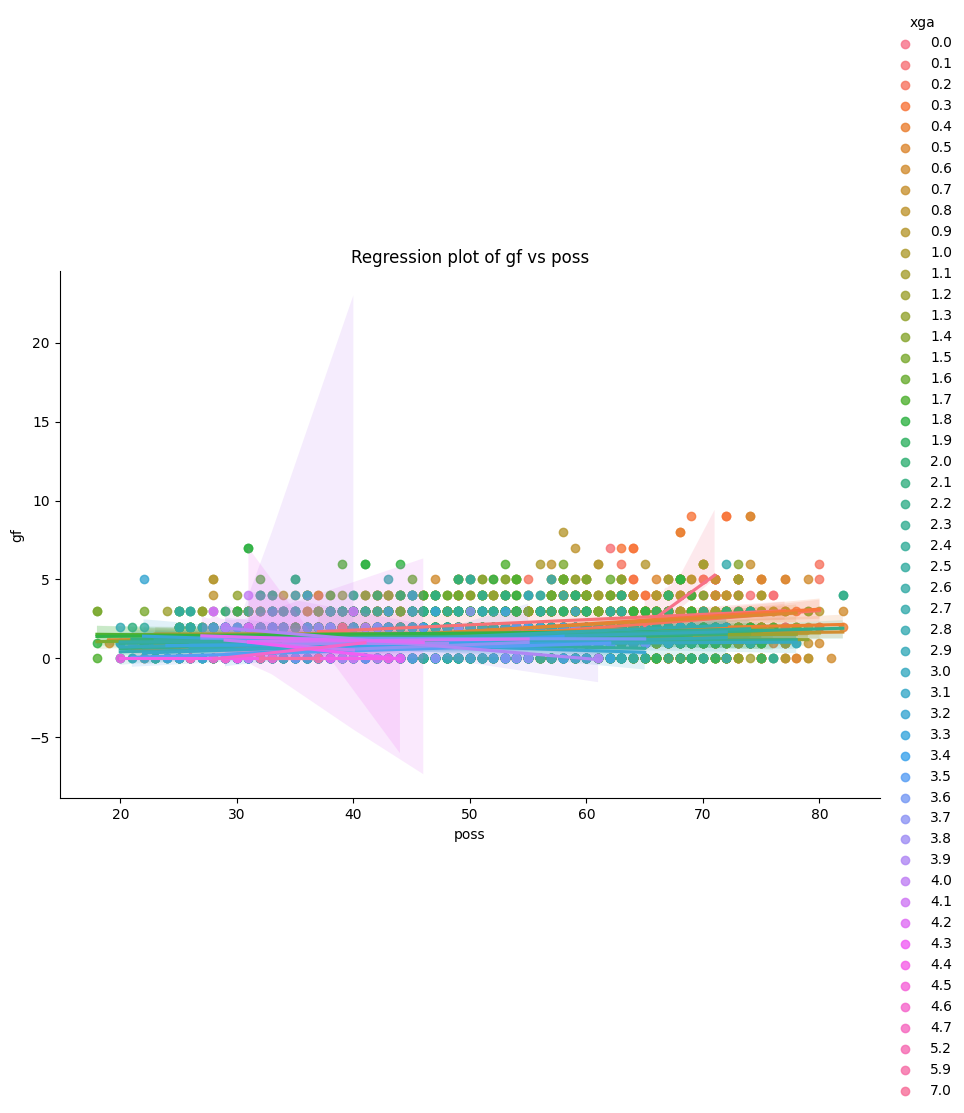

In [55]:
sns.lmplot(x='poss', y='gf', data=df, hue='xga', height=6, aspect=1.5)
plt.title("Regression plot of gf vs poss")
plt.show()

# Time series plot with Rolling Average

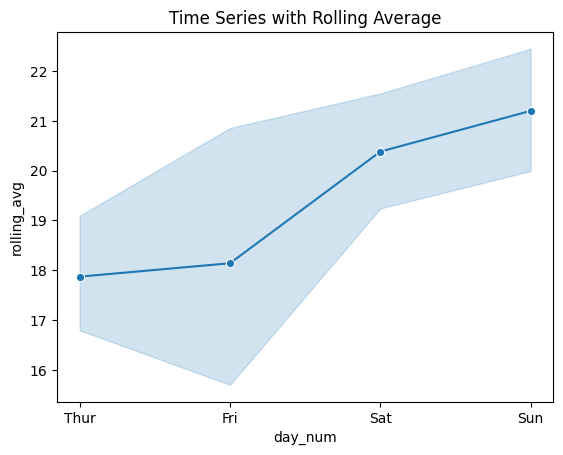

In [56]:
df_tips = sns.load_dataset("tips")
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill'].rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg', data=df_tips,marker='o')
plt.xticks(ticks=[0,1,2,3],labels=['Thur','Fri','Sat','Sun'])
plt.title("Time Series with Rolling Average")
plt.show()